# Underwater image enhancement (UIEB) with the UGAN architecture

* **Model**: UGAN of Fabbri, Islam & Sattar (`IRVLab/UGAN`), architecture as in the paper (Section 1). Generator: fully-convolutional U-Net (4x4 stride-2 convolutions, BatchNorm + LeakyReLU(0.2) in the encoder, transposed convolutions + ReLU without BatchNorm in the decoder, tanh output, skip connections). Critic: PatchGAN without BatchNorm (32x32x1 output for a 256x256 image).
* **Adversarial training**: WGAN-GP (gradient-penalty weight 10, 5 critic steps per generator step, Adam 1e-4). Set `USE_ADV = False` to train the generator on the L1 + SSIM loss alone.
* **Training recipe**: L1 + SSIM loss (+ a small adversarial term), Adam, ReduceLROnPlateau on the generator (Section 2). The "Loss" printed and logged every epoch (train and validation) is the L1 + SSIM loss.
* **Training loop** (Section 4) follows `ASRD_U_Mamba.ipynb`: after every epoch it prints the loss and all 4 metrics (PSNR, SSIM, LPIPS, UIQM) for train and validation, writes one CSV row, keeps **only the single best generator** (highest validation PSNR) and stops early after `PATIENCE` epochs without improvement. There are no checkpoints and no resume.

Files written under `Dehaze/`:

| file | content |
|---|---|
| `logs/training_log.csv` | one row per epoch: LR, train loss + PSNR/SSIM/LPIPS/UIQM, val loss + PSNR/SSIM/LPIPS/UIQM, critic loss, Wasserstein estimate, timings, throughput, GPU memory, `is_best` |
| `logs/metrics_test.csv` | final test metrics |
| `logs/timing_summary.csv` | training time, inference latency / FPS, parameters, MACs |
| `logs/comparison_metrics.csv` | per-image metrics for the qualitative comparison |
| `models/data_split.csv` | train/val/test file lists |
| `models/best_model_ugan.pth` | best generator (`state_dict`, selected by validation PSNR) |
| `models/dehaze_final.pth` | generator weights + config after the test cell |

Reference: Fabbri, Islam & Sattar, "Enhancing Underwater Imagery using Generative Adversarial Networks", arXiv:1801.04011. Code: https://github.com/IRVLab/UGAN

The paper fixes the kernel sizes, strides, normalisation / activation pattern, tanh output, the PatchGAN critic without BatchNorm, WGAN-GP and the hyper-parameters. It does not list the number of U-Net levels or the channel widths; this notebook uses the pix2pix U-Net widths (64-128-256-512-512-512-512-512, 8 levels for 256x256 input).

# Imports

In [1]:
# %pip install -q lpips thop scikit-image opencv-python scipy   # uncomment on a fresh environment
import sys
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import time
import csv
import copy
import math
import random
import datetime
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import lpips  # pip install lpips

e:\under_water_dehazing\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = os.path.abspath(".")
DATASET_ROOT = os.path.join(PROJECT_ROOT, "dataset")
RAW_DIR = os.path.join(DATASET_ROOT, "raw-890")          # degraded inputs
REF_DIR = os.path.join(DATASET_ROOT, "reference-890")    # clean reference images (same file names)
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "models")
LOG_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "logs")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "comparison_outputs")
for d in [MODEL_SAVE_DIR, LOG_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- data / optimisation (UGAN paper: Adam, lr 1e-4)
IMG_SIZE = 256
BATCH_SIZE = 8             # the paper used 32
EPOCHS = 100
LR_G = 1e-4
LR_D = 1e-4
ADAM_BETAS = (0.5, 0.9)    # usual WGAN-GP setting (the paper only states the learning rate)
LR_PATIENCE = 5            # ReduceLROnPlateau on the generator, monitors validation PSNR
LR_FACTOR = 0.5
LR_MIN = 1e-6
GRAD_CLIP = 1.0            # generator grad-norm clip (as in the WaterNet notebook); None = off

# ---- loss weights (L1 + SSIM, + small adversarial term)
LAMBDA_L1 = 1.0
LAMBDA_SSIM = 0.2
# The paper uses  -D(G(x)) + 100 * L1  on images in [-1, 1].  The losses here are computed on [0, 1] images, where
# L1 is half as large, so the same 1 : 100 ratio becomes 1 : 200 -> weight 0.005 for the adversarial term.
LAMBDA_ADV = 0.005

# ---- UGAN architecture / WGAN-GP
GEN_CHANNELS = (64, 128, 256, 512, 512, 512, 512, 512)   # one entry per U-Net level (8 levels -> 1x1 bottleneck for 256x256)
N_CRITIC = 5               # critic updates per generator update (paper)
LAMBDA_GP = 10.0           # gradient-penalty weight (paper)
USE_ADV = True             # False -> generator is trained on L1 + SSIM only, the critic is not used

# ---- data split (UIEB has no official split)
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
TRAIN_UIQM = True                  # UIQM is a slow numpy metric; True = also computed on the train set every epoch
                                   # (False -> train UIQM is logged as NaN, val/test UIQM are always computed)

# ---- training loop (same scheme as ASRD_U_Mamba.ipynb)
PATIENCE = 25              # early stopping: stop after this many epochs without a new best val PSNR
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_model_ugan.pth")   # the only model file written during training
USE_TORCH_COMPILE = True   # compiles the generator only (skipped automatically on Windows / without Triton)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- speed knobs -------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True   # auto-tune conv algorithms (fixed input size)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_num_threads(4)  # cap CPU threads so workers don't fight each other

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# The U-Net halves H and W at every level down to a 1x1 bottleneck, so IMG_SIZE must equal 2**len(GEN_CHANNELS)
# (or a multiple of it); the critic downsamples by 8 and outputs an (IMG_SIZE/8)^2 map of patch scores.
assert IMG_SIZE % (2 ** len(GEN_CHANNELS)) == 0, "IMG_SIZE must be divisible by 2**len(GEN_CHANNELS)"

for p in [RAW_DIR, REF_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory: {p}")

print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print("Raw images:", len(os.listdir(RAW_DIR)), "Reference images:", len(os.listdir(REF_DIR)))
print(f"USE_ADV={USE_ADV} N_CRITIC={N_CRITIC} LAMBDA_GP={LAMBDA_GP} | loss = {LAMBDA_L1}*L1 + {LAMBDA_SSIM}*(1-SSIM)"
      + (f" + {LAMBDA_ADV}*adv" if USE_ADV else ""))

Device: cuda (NVIDIA GeForce RTX 3060)
Raw images: 890 Reference images: 890
USE_ADV=True N_CRITIC=5 LAMBDA_GP=10.0 | loss = 1.0*L1 + 0.2*(1-SSIM) + 0.005*adv


## Dataset Loader

In [3]:
# ============================================================================
# Helper utilities  (np_to_tensor, tensor_to_uint8, compute_uiqm,
#                    ssim_torch, sync, lpips_fn)
# ============================================================================
import torch, numpy as np
import lpips as _lpips_module

# ---------- tensor <-> numpy helpers ----------------------------------------

def np_to_tensor(img_uint8):
    """uint8 HxWx3 numpy array -> float32 3xHxW tensor in [0,1]."""
    return torch.from_numpy(img_uint8.astype(np.float32) / 255.0).permute(2, 0, 1)


def tensor_to_uint8(t):
    """3xHxW (or 1x3xHxW) float tensor in [0,1] -> uint8 HxWx3 numpy array."""
    if t.dim() == 4:
        t = t.squeeze(0)
    return (t.detach().clamp(0, 1).permute(1, 2, 0).cpu().float().numpy() * 255.0).round().astype(np.uint8)


# ---------- CUDA sync helper ------------------------------------------------

def sync():
    """Block until all CUDA kernels complete (no-op on CPU)."""
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# ---------- SSIM (differentiable, batched) ----------------------------------

def _gaussian_kernel_1d(size=11, sigma=1.5):
    x = torch.arange(size, dtype=torch.float32) - size // 2
    k = torch.exp(-x ** 2 / (2 * sigma ** 2))
    return k / k.sum()


def _ssim_kernel(size=11, sigma=1.5):
    k1d = _gaussian_kernel_1d(size, sigma)
    k2d = k1d.unsqueeze(1) * k1d.unsqueeze(0)        # (size, size)
    return k2d.unsqueeze(0).unsqueeze(0)              # (1, 1, size, size)


_SSIM_WIN = None        # cached kernel (keyed by device + dtype)
_SSIM_WIN_KEY = None


def ssim_torch(pred, target, size=11, sigma=1.5, C1=0.01**2, C2=0.03**2):
    """Per-image differentiable SSIM.  Returns shape (B,).
    Always computed in float32: the model output can be float16 (AMP) while the target is float32, and
    variance = E[x^2] - E[x]^2 is numerically unreliable in float16."""
    global _SSIM_WIN, _SSIM_WIN_KEY
    pred, target = pred.float(), target.float()
    key = (pred.device, torch.float32)
    if _SSIM_WIN is None or _SSIM_WIN_KEY != key:
        _SSIM_WIN = _ssim_kernel(size, sigma).to(pred.device, dtype=torch.float32)
        _SSIM_WIN_KEY = key
    B, C, H, W = pred.shape
    # Treat all channels independently then average
    p = pred.reshape(B * C, 1, H, W)
    t = target.reshape(B * C, 1, H, W)
    pad = size // 2
    mu_p  = torch.nn.functional.conv2d(p, _SSIM_WIN, padding=pad)
    mu_t  = torch.nn.functional.conv2d(t, _SSIM_WIN, padding=pad)
    mu_p2 = mu_p ** 2
    mu_t2 = mu_t ** 2
    mu_pt = mu_p * mu_t
    sig_p2 = torch.nn.functional.conv2d(p * p, _SSIM_WIN, padding=pad) - mu_p2
    sig_t2 = torch.nn.functional.conv2d(t * t, _SSIM_WIN, padding=pad) - mu_t2
    sig_pt = torch.nn.functional.conv2d(p * t, _SSIM_WIN, padding=pad) - mu_pt
    num = (2 * mu_pt + C1) * (2 * sig_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sig_p2 + sig_t2 + C2)
    ssim_map = num / den.clamp_min(1e-8)
    ssim_per_channel = ssim_map.reshape(B, C, H, W).mean(dim=(1, 2, 3))   # (B,)
    return ssim_per_channel


# ---------- LPIPS (evaluation metric only -- not part of the loss) -----------------------------

lpips_fn = _lpips_module.LPIPS(net="alex", verbose=False).to(DEVICE)


# ---------- UIQM (Underwater Image Quality Measure) ------------------------
# Ref: Panetta et al. 2016.  Pure-numpy implementation, runs on CPU.
# Same implementation as in the WaterNet notebook, so the UIQM numbers of the two models are comparable.

def _uicm(img_f32):
    """Chroma measure."""
    rg = img_f32[:, :, 0] - img_f32[:, :, 1]
    yb = 0.5 * (img_f32[:, :, 0] + img_f32[:, :, 1]) - img_f32[:, :, 2]
    def _stats(x):
        mu = x.mean(); sigma = x.std()
        # asymmetric alpha-trimmed mean
        flat = x.flatten(); flat.sort()
        n = len(flat); lo, hi = int(0.1 * n), int(0.9 * n)
        alpha_mu = flat[lo:hi].mean() if hi > lo else mu
        return alpha_mu, sigma
    mu_rg, sig_rg = _stats(rg)
    mu_yb, sig_yb = _stats(yb)
    return -0.0268 * np.sqrt(mu_rg**2 + mu_yb**2) + 0.1586 * np.sqrt(sig_rg**2 + sig_yb**2)


def _uism(img_uint8):
    """Sharpness measure (Sobel)."""
    from scipy import ndimage
    score = 0.0
    weights = [0.299, 0.587, 0.114]
    for ch, w in enumerate(weights):
        chan = img_uint8[:, :, ch].astype(np.float32)
        sx = ndimage.sobel(chan, axis=0); sy = ndimage.sobel(chan, axis=1)
        edges = np.hypot(sx, sy)
        # EME (Enhancement Measure Estimation) with k=8 blocks
        h, wd = edges.shape
        bh, bw = max(h // 8, 1), max(wd // 8, 1)
        eme = 0.0; count = 0
        for r in range(0, h, bh):
            for c in range(0, wd, bw):
                blk = edges[r:r+bh, c:c+bw]
                mx = blk.max(); mn = blk.min()
                if mx > 0 and mn > 0:
                    eme += np.log(mx / (mn + 1e-5))
                    count += 1
        score += w * (2.0 / max(count, 1)) * eme
    return score


def _uiconm(img_f32):
    """Contrast measure."""
    from scipy import ndimage
    gray = 0.299 * img_f32[:, :, 0] + 0.587 * img_f32[:, :, 1] + 0.114 * img_f32[:, :, 2]
    ambe = np.abs(ndimage.uniform_filter(gray, size=8) - gray.mean())
    return np.log1p(ambe.mean())


def compute_uiqm(img_uint8):
    """UIQM score for a uint8 HxWx3 numpy array."""
    img_f32 = img_uint8.astype(np.float32) / 255.0
    c1, c2, c3 = 0.0282, 0.2953, 3.5753
    return c1 * _uicm(img_f32) + c2 * _uism(img_uint8) + c3 * _uiconm(img_f32)

print("Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)")

e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)


In [4]:
class UIEBDataset(Dataset):
    """Returns (degraded image I, reference image J), both 3xHxW float32 in [0,1].
    Augmentation uses fast numpy flips + brightness jitter; the heavy rotation is
    removed (flip-only is ~10x faster and sufficient for regularisation).
    """
    def __init__(self, pairs, img_size=256, train=False, cache_in_memory=True):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train
        self.cache_in_memory = cache_in_memory
        if self.cache_in_memory:
            # Pre-load & resize into contiguous uint8 arrays → eliminates disk I/O per batch
            self.cached_pairs = [
                (self._load(raw_p), self._load(ref_p)) for raw_p, ref_p in pairs
            ]

    def __len__(self):
        return len(self.pairs)

    def _load(self, path):
        with Image.open(path) as im:
            img = np.array(im.convert("RGB"))
        return cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

    def _augment(self, raw, ref):
        # ---- fast numpy augmentations (no warpAffine / no rotation) ----
        if random.random() < 0.5:
            raw, ref = np.fliplr(raw).copy(), np.fliplr(ref).copy()   # horizontal flip
        if random.random() < 0.5:
            raw, ref = np.flipud(raw).copy(), np.flipud(ref).copy()   # vertical flip
        # brightness jitter on input only (cheap scalar multiply)
        factor = random.uniform(0.85, 1.15)
        raw = np.clip(raw.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        return raw, ref

    def __getitem__(self, idx):
        if self.cache_in_memory:
            raw, ref = self.cached_pairs[idx]
            raw, ref = raw.copy(), ref.copy()
        else:
            raw_path, ref_path = self.pairs[idx]
            raw, ref = self._load(raw_path), self._load(ref_path)
        if self.train:
            raw, ref = self._augment(raw, ref)
        return np_to_tensor(raw), np_to_tensor(ref)

# 1. Base Model 

The UGAN architecture (U-Net generator + PatchGAN critic) as described in Fabbri et al. and the `IRVLab/UGAN` repository. The generator works on images in [-1, 1] (tanh output); `enhance()` in the next cell wraps it so that the rest of the notebook only sees images in [0, 1], like the WaterNet notebook.

In [5]:
# ======================= UGAN (Fabbri, Islam & Sattar, arXiv:1801.04011) =======================
def init_weights(m):
    """DCGAN-style initialisation (the paper does not specify one)."""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


class UGANGenerator(nn.Module):
    """Fully-convolutional encoder-decoder "U-Net".
    Every convolution uses a 4x4 kernel with stride 2.
      encoder : Conv -> BatchNorm -> LeakyReLU(0.2)
      decoder : ConvTranspose -> ReLU   (no BatchNorm); the last layer uses Tanh
      skips   : the output of encoder layer i is concatenated to the input of decoder layer n-i+1
    Input / output are images in [-1, 1]."""
    def __init__(self, in_ch=3, out_ch=3, channels=(64, 128, 256, 512, 512, 512, 512, 512)):
        super().__init__()
        chs, n = list(channels), len(channels)
        self.n = n

        self.enc = nn.ModuleList()
        c_in = in_ch
        for c in chs:
            self.enc.append(nn.Sequential(
                nn.Conv2d(c_in, c, 4, 2, 1, bias=False), nn.BatchNorm2d(c), nn.LeakyReLU(0.2, inplace=True)))
            c_in = c

        dec_out = chs[-2::-1]                      # decoder widths: reversed(chs[:-1])
        self.up = nn.ModuleList()
        c_in = chs[-1]
        for k in range(n - 1):
            self.up.append(nn.Sequential(nn.ConvTranspose2d(c_in, dec_out[k], 4, 2, 1), nn.ReLU(inplace=True)))
            c_in = dec_out[k] + chs[n - 2 - k]     # width after concatenating the matching encoder feature
        self.out = nn.Sequential(nn.ConvTranspose2d(c_in, out_ch, 4, 2, 1), nn.Tanh())
        self.apply(init_weights)

    def forward(self, x):
        feats = []
        h = x
        for enc in self.enc:
            h = enc(h)
            feats.append(h)
        for k, up in enumerate(self.up):
            h = torch.cat([up(h), feats[self.n - 2 - k]], dim=1)
        return self.out(h)


class UGANDiscriminator(nn.Module):
    """PatchGAN critic (DCGAN style) with NO normalisation layers -- BatchNorm would invalidate the per-sample
    gradient penalty of WGAN-GP. For a 256x256 input it outputs a 32x32x1 map of patch scores."""
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        act = lambda: nn.LeakyReLU(0.2)
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1), act(),            # 256 -> 128
            nn.Conv2d(base, base * 2, 4, 2, 1), act(),         # 128 -> 64
            nn.Conv2d(base * 2, base * 4, 4, 2, 1), act(),     # 64  -> 32
            nn.Conv2d(base * 4, base * 8, 3, 1, 1), act(),     # 32  -> 32
            nn.Conv2d(base * 8, 1, 3, 1, 1))                   # 32x32x1 patch scores (no sigmoid: Wasserstein critic)
        self.apply(init_weights)

    def forward(self, x):
        return self.net(x)

In [6]:
generator = UGANGenerator(channels=GEN_CHANNELS).to(DEVICE)
discriminator = UGANDiscriminator().to(DEVICE)


def count_params(*modules):
    return sum(p.numel() for m in modules if m is not None for p in m.parameters())


def enhance(I):
    """Batch of degraded images in [0, 1] -> UGAN generator (works on [-1, 1]) -> enhanced images in [0, 1]."""
    return (generator(I * 2.0 - 1.0) + 1.0) / 2.0


class DehazePipeline(nn.Module):
    """Wrapper used only for MAC counting (takes / returns images in [0, 1])."""
    def __init__(self, gen):
        super().__init__()
        self.gen = gen

    def forward(self, I):
        return (self.gen(I * 2.0 - 1.0) + 1.0) / 2.0


# shape sanity check: the output must have the same H x W as the input
generator.eval(); discriminator.eval()
with torch.no_grad():
    _y = enhance(torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
    _c = discriminator(torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE) * 2.0 - 1.0)
assert _y.shape == (1, 3, IMG_SIZE, IMG_SIZE), f"unexpected generator output shape {tuple(_y.shape)}"
assert 0.0 <= _y.min().item() and _y.max().item() <= 1.0, "UGAN ends with a tanh -> enhance() output must be in [0,1]"
assert _c.shape == (1, 1, IMG_SIZE // 8, IMG_SIZE // 8), f"unexpected critic output shape {tuple(_c.shape)}"
del _y, _c
print(f"UGAN generator parameters: {count_params(generator) / 1e6:.2f} M | critic parameters: {count_params(discriminator) / 1e6:.2f} M | output shapes OK")

UGAN generator parameters: 54.41 M | critic parameters: 1.84 M | output shapes OK


# 2.Losses, Optimizers, and Metrics

In [7]:
class DehazeMetrics:
    """Accumulates PSNR / SSIM / LPIPS (/ UIQM) over batches. Predictions are quantised to 8 bit first so that
    validation, test and the qualitative comparison (uint8 PNGs) all measure the same thing."""
    def __init__(self, compute_uiqm_flag=False, compute_lpips_flag=False):
        self.compute_uiqm_flag = compute_uiqm_flag
        self.compute_lpips_flag = compute_lpips_flag
        self.sums = {"psnr": 0.0, "ssim": 0.0, "lpips": 0.0, "uiqm": 0.0}
        self.n = 0

    def update(self, pred, target):
        # dtype fix: pred may be float16 (AMP). Quantising in float16 is inexact, and mixing float16/float32
        # in SSIM / LPIPS raises a dtype error -> do every metric in float32.
        pred, target = pred.detach().float(), target.detach().float()
        pred_q = torch.round(pred.clamp(0, 1) * 255.0) / 255.0
        mse = ((pred_q - target) ** 2).mean(dim=(1, 2, 3)).clamp_min(1e-10)
        self.sums["psnr"] += (10.0 * torch.log10(1.0 / mse)).sum().item()
        self.sums["ssim"] += ssim_torch(pred_q, target).sum().item()
        if self.compute_lpips_flag:
            self.sums["lpips"] += lpips_fn(pred_q, target, normalize=True).sum().item()
        if self.compute_uiqm_flag:
            for img in pred_q:
                self.sums["uiqm"] += compute_uiqm(tensor_to_uint8(img))
        self.n += pred.size(0)

    def compute(self):
        n = max(self.n, 1)
        out = {k: v / n for k, v in self.sums.items()}
        if not self.compute_uiqm_flag:
            out["uiqm"] = float("nan")
        if not self.compute_lpips_flag:
            out["lpips"] = float("nan")
        return out


def gradient_penalty(critic, real, fake):
    """WGAN-GP: (||grad_xhat D(xhat)||_2 - 1)^2 on random points between real and fake images (images in [-1, 1])."""
    eps = torch.rand(real.size(0), 1, 1, 1, device=real.device)
    xhat = (eps * real + (1.0 - eps) * fake).requires_grad_(True)
    out = critic(xhat)
    grad = torch.autograd.grad(outputs=out.sum(), inputs=xhat, create_graph=True)[0]   # samples are independent (no BatchNorm)
    return ((grad.flatten(1).norm(2, dim=1) - 1.0) ** 2).mean()


# ------------------------------------------------------------------ optimisers + scheduler + AMP scaler
optimizer_G = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=ADAM_BETAS)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=ADAM_BETAS)
scheduler_G = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN      # monitors val PSNR
)
AMP_ENABLED = DEVICE.type == "cuda"
# AMP is used for the generator only. The critic and the gradient penalty (double backward) stay in float32.
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

# 3. Dataloader

In [8]:
def collect_pairs(raw_dir, ref_dir):
    """Return sorted list of (raw_path, ref_path) tuples for files present in both dirs."""
    raw_files = {p.name: p for p in Path(raw_dir).iterdir() if p.is_file()}
    ref_files = {p.name: p for p in Path(ref_dir).iterdir() if p.is_file()}
    common = sorted(raw_files.keys() & ref_files.keys())
    return [(raw_files[n], ref_files[n]) for n in common]


def split_pairs(pairs, val_fraction, test_fraction, seed):
    """Randomly split pairs into train / val / test lists."""
    rng = random.Random(seed)
    shuffled = list(pairs)
    rng.shuffle(shuffled)
    n = len(shuffled)
    n_test = max(1, int(n * test_fraction))
    n_val  = max(1, int(n * val_fraction))
    test  = shuffled[:n_test]
    val   = shuffled[n_test:n_test + n_val]
    train = shuffled[n_test + n_val:]
    return train, val, test


num_workers = 0   # parallel data workers; set to 0 if you see multiprocessing errors

all_pairs = collect_pairs(RAW_DIR, REF_DIR)
if len(all_pairs) == 0:
    raise RuntimeError(f"No raw/reference pairs found in {RAW_DIR} and {REF_DIR}")
train_pairs, val_pairs, test_pairs = split_pairs(all_pairs, VAL_FRACTION, TEST_FRACTION, SEED)

# Save the split so results are reproducible / reportable
with open(os.path.join(MODEL_SAVE_DIR, "data_split.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "file"])
    for name, pairs in [("train", train_pairs), ("val", val_pairs), ("test", test_pairs)]:
        for raw_p, _ in pairs:
            w.writerow([name, raw_p.name])

train_dataset = UIEBDataset(train_pairs, IMG_SIZE, train=True)
val_dataset = UIEBDataset(val_pairs, IMG_SIZE, train=False)
test_dataset = UIEBDataset(test_pairs, IMG_SIZE, train=False)

_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                  persistent_workers=num_workers > 0,
                  prefetch_factor=2 if num_workers > 0 else None)
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True,      # drop_last: BatchNorm needs > 1 sample per batch
                          generator=torch.Generator().manual_seed(SEED), **_loader_kw)
val_loader = DataLoader(val_dataset, shuffle=False, **_loader_kw)
test_loader = DataLoader(test_dataset, shuffle=False, **_loader_kw)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 712
Val samples: 89
Test samples: 89


In [9]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} psnr={metrics['psnr']:.3f} ssim={metrics['ssim']:.4f} "
        f"lpips={metrics['lpips']:.4f} uiqm={metrics['uiqm']:.3f}"
    )


def print_metric_block(title, res):
    """Loss + the 4 metrics, one per line (same layout as ASRD_U_Mamba.ipynb)."""
    print(f"\n{title}")
    print("-" * 60)
    print(f"Loss       : {res['loss']:.4f}")
    print(f"PSNR (dB)  : {res['psnr']:.3f}")
    print(f"SSIM       : {res['ssim']:.4f}")
    print(f"LPIPS      : {res['lpips']:.4f}")
    print(f"UIQM       : {res['uiqm']:.3f}")


def composite_loss(pred, target):
    """L1 + SSIM content loss. This is the "Loss" that is printed and logged (train and validation).
    Always float32 (pred is float16 when it comes out of an autocast region). pred / target are images in [0, 1]."""
    pred, target = pred.float(), target.float()
    l_l1 = F.l1_loss(pred, target)
    l_ssim = 1.0 - ssim_torch(pred, target).mean()          # SSIM loss = 1 - SSIM
    loss = LAMBDA_L1 * l_l1 + LAMBDA_SSIM * l_ssim
    return loss, l_l1, l_ssim


def train_one_epoch(loader, epoch=None, total_epochs=None):
    """One UGAN epoch. For every mini-batch: N_CRITIC WGAN-GP critic updates, then one generator update on
    L1 + SSIM (+ LAMBDA_ADV * adversarial term). Returns mean loss + PSNR/SSIM/LPIPS/UIQM + GAN statistics + timing.
    "loss" is the L1 + SSIM loss; "loss_G" is the full generator objective (= loss when USE_ADV is False).
    The generator runs under AMP autocast; the critic, the gradient penalty, the loss and the metrics are float32."""
    generator.train()
    discriminator.train()
    metrics = DehazeMetrics(compute_uiqm_flag=TRAIN_UIQM, compute_lpips_flag=True)
    sums = {"loss": 0.0, "loss_G": 0.0, "loss_D": 0.0, "w_dist": 0.0}
    n, data_time = 0, 0.0
    sync()
    t_start = t_prev = time.perf_counter()
    desc = f"Epoch {epoch}/{total_epochs} [Train]" if (epoch and total_epochs) else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    for I, J in pbar:
        data_time += time.perf_counter() - t_prev
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        real = J * 2.0 - 1.0                              # UGAN works on [-1, 1]
        with torch.amp.autocast(DEVICE.type, enabled=AMP_ENABLED):
            fake = generator(I * 2.0 - 1.0)               # float16 under autocast
        fake = fake.float()                               # dtype fix: float32 for the critic, loss and metrics
        fake01 = (fake + 1.0) / 2.0

        # ---- critic: N_CRITIC updates on this mini-batch (fresh interpolation points every step)
        loss_D = torch.zeros((), device=DEVICE)
        w_dist = torch.zeros((), device=DEVICE)
        if USE_ADV:
            fake_d = fake.detach()
            for _ in range(N_CRITIC):
                d_real = discriminator(real).mean()
                d_fake = discriminator(fake_d).mean()
                loss_D = d_fake - d_real + LAMBDA_GP * gradient_penalty(discriminator, real, fake_d)
                optimizer_D.zero_grad(set_to_none=True)
                loss_D.backward()
                optimizer_D.step()
            w_dist = (d_real - d_fake).detach()           # Wasserstein-distance estimate of the last critic step

        # ---- generator: L1 + SSIM (+ adversarial term), float32 loss outside autocast
        loss, l_l1, l_ssim = composite_loss(fake01, J)
        loss_G = loss
        if USE_ADV:
            for p in discriminator.parameters():
                p.requires_grad_(False)
            loss_G = loss - LAMBDA_ADV * discriminator(fake).mean()
            for p in discriminator.parameters():
                p.requires_grad_(True)

        optimizer_G.zero_grad(set_to_none=True)
        scaler.scale(loss_G).backward()
        if GRAD_CLIP:
            scaler.unscale_(optimizer_G)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=GRAD_CLIP)
        scaler.step(optimizer_G)
        scaler.update()

        bs = I.size(0)
        for k, v in (("loss", loss), ("loss_G", loss_G), ("loss_D", loss_D), ("w_dist", w_dist)):
            sums[k] += v.item() * bs
        n += bs
        with torch.no_grad():
            metrics.update(fake01.detach(), J)
        pbar.set_postfix(loss=f"{loss.item():.4f}", l1=f"{l_l1.item():.4f}", ssim=f"{l_ssim.item():.4f}")
        t_prev = time.perf_counter()
    sync()
    elapsed = time.perf_counter() - t_start
    out = {k: v / max(n, 1) for k, v in sums.items()}
    out.update(metrics.compute())
    out.update(time_s=elapsed, data_time_s=data_time, imgs_per_s=n / max(elapsed, 1e-9))
    return out


@torch.no_grad()
def evaluate(loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Val"):
    """Returns a dict: L1 + SSIM loss, l1, psnr, ssim, lpips, uiqm, time_s (all 4 metrics on by default)."""
    generator.eval()
    metrics = DehazeMetrics(compute_uiqm_flag=compute_uiqm_flag, compute_lpips_flag=compute_lpips_flag)
    sums = {"loss": 0.0, "l1": 0.0}
    n = 0
    sync()
    t_start = time.perf_counter()
    pbar = tqdm(loader, desc=f"Evaluating [{desc}]", leave=False)
    for I, J in pbar:
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(DEVICE.type, enabled=AMP_ENABLED):
            pred = enhance(I)
        pred = pred.float()                                   # dtype fix: back to float32 before loss / metrics
        loss, l_l1, _ = composite_loss(pred, J)
        bs = I.size(0)
        sums["loss"] += loss.item() * bs
        sums["l1"] += l_l1.item() * bs
        n += bs
        metrics.update(pred, J)
        pbar.set_postfix(loss=f"{loss.item():.4f}", l1=f"{l_l1.item():.4f}")
    sync()
    res = {k: v / max(n, 1) for k, v in sums.items()}
    res.update(metrics.compute())
    res["time_s"] = time.perf_counter() - t_start
    return res

# 4.Training Loop

In [10]:
best_model_path = BEST_MODEL_PATH
train_log_path = os.path.join(LOG_DIR, "training_log.csv")

LOG_FIELDS = (
    ["epoch", "timestamp", "lr_G"]
    + [f"train_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + [f"val_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + ["train_loss_G", "train_loss_D", "train_w_dist",
       "train_time_s", "data_time_s", "val_time_s", "epoch_time_s", "cumulative_time_s",
       "train_imgs_per_s", "gpu_peak_mem_mb", "is_best"]
)


def save_atomic(obj, path):
    """Write to a temp file, then rename -> a crash mid-save can never leave a corrupt model file."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


# ---- torch.compile (generator only): not supported on Windows (requires Triton) ----
raw_generator = getattr(generator, "_orig_mod", generator)     # un-compiled module: its state_dict has clean key names
if USE_TORCH_COMPILE and hasattr(torch, "compile") and sys.platform != "win32":
    try:
        generator = torch.compile(raw_generator)               # compile the raw module, so re-running this cell is safe
        print("torch.compile() enabled for the generator", flush=True)
    except Exception as e:
        print(f"torch.compile() skipped: {e}", flush=True)
else:
    print("torch.compile() skipped (disabled / Windows / Triton not available) -- other optimisations still active", flush=True)

best_val_psnr, best_epoch, counter, cum_time = -float("inf"), 0, 0, 0.0

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)), flush=True)

with open(train_log_path, "w", newline="") as log_file:
    writer = csv.DictWriter(log_file, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for epoch in range(EPOCHS):
        print("\n" + "=" * 80)
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("=" * 80, flush=True)

        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        sync()
        epoch_start = time.perf_counter()
        lr_used = optimizer_G.param_groups[0]["lr"]

        # ------------------ Training & Validation ------------------
        tr = train_one_epoch(train_loader, epoch=epoch + 1, total_epochs=EPOCHS)
        va = evaluate(val_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc=f"Epoch {epoch + 1}/{EPOCHS} Val")
        scheduler_G.step(va["psnr"])

        sync()
        epoch_time = time.perf_counter() - epoch_start
        cum_time += epoch_time
        peak_mem = torch.cuda.max_memory_allocated() / 2 ** 20 if DEVICE.type == "cuda" else 0.0

        # ------------------ CHECKPOINT: best generator only (highest validation PSNR; GAN losses are not comparable across epochs) ------------------
        is_best = va["psnr"] > best_val_psnr
        if is_best:
            best_val_psnr, best_epoch, counter = float(va["psnr"]), epoch + 1, 0
            save_atomic(raw_generator.state_dict(), best_model_path)
        else:
            counter += 1

        # ------------------ CSV log (flushed every epoch, so it survives a crash) ------------------
        row = {"epoch": epoch + 1, "timestamp": datetime.datetime.now().isoformat(timespec="seconds"), "lr_G": lr_used}
        row.update({f"train_{k}": tr[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update({f"val_{k}": va[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update(train_loss_G=tr["loss_G"], train_loss_D=tr["loss_D"], train_w_dist=tr["w_dist"],
                   train_time_s=tr["time_s"], data_time_s=tr["data_time_s"], val_time_s=va["time_s"],
                   epoch_time_s=epoch_time, cumulative_time_s=cum_time,
                   train_imgs_per_s=tr["imgs_per_s"], gpu_peak_mem_mb=peak_mem, is_best=int(is_best))
        writer.writerow(row)
        log_file.flush()

        # ------------------ console: loss + 4 metrics, train and validation ------------------
        print_metric_block("TRAIN METRICS", tr)
        print_metric_block("VALIDATION METRICS", va)
        print("\nTRAINING INFORMATION")
        print("-" * 60)
        print(f"LR (G)     : {lr_used:.2e}")
        if USE_ADV:
            print(f"GAN        : loss_G={tr['loss_G']:.4f} loss_D={tr['loss_D']:.4f} W-dist={tr['w_dist']:.4f}")
        print(f"Time       : train={tr['time_s']:.1f}s val={va['time_s']:.1f}s epoch={epoch_time:.1f}s total={cum_time / 60:.1f}min"
              + (f" | peak GPU mem={peak_mem:.0f}MB" if DEVICE.type == "cuda" else ""), flush=True)

        if is_best:
            print("\nBest model saved!")
            print(f"Validation PSNR : {best_val_psnr:.3f} dB")
        else:
            print(f"\nNo improvement for {counter} epoch(s).")

        # ------------------ EARLY STOPPING ------------------
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

train_end = time.time()
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Training time (this session): {train_end - train_start:.1f}s")
print(f"Best Validation PSNR : {best_val_psnr:.3f} dB")
print(f"Best Epoch           : {best_epoch}")
print(f"Best Model Saved At  : {best_model_path}")
print(f"Training log saved to: {train_log_path}")
print("=" * 80)

torch.compile() skipped (disabled / Windows / Triton not available) -- other optimisations still active
Training start: 2026-10-01 13:52:31

Epoch 1/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.2120
PSNR (dB)  : 16.903
SSIM       : 0.5516
LPIPS      : 0.4190
UIQM       : 3.309

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1561
PSNR (dB)  : 18.610
SSIM       : 0.7190
LPIPS      : 0.3107
UIQM       : 3.473

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 1.00e-04
GAN        : loss_G=0.2120 loss_D=-0.0040 W-dist=0.0321
Time       : train=55.4s val=6.6s epoch=62.0s total=1.0min | peak GPU mem=5272MB

Best model saved!
Validation PSNR : 18.610 dB

Epoch 2/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1433
PSNR (dB)  : 18.946
SSIM       : 0.7564
LPIPS      : 0.2733
UIQM       : 3.554

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1341
PSNR (dB)  : 19.380
SSIM       : 0.7854
LPIPS      : 0.2552
UIQM       : 3.564

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 1.00e-04
GAN        : loss_G=0.1436 loss_D=-0.0012 W-dist=0.0179
Time       : train=38.9s val=0.7s epoch=39.6s total=1.7min | peak GPU mem=1741MB

Best model saved!
Validation PSNR : 19.380 dB

Epoch 3/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1317
PSNR (dB)  : 19.357
SSIM       : 0.7949
LPIPS      : 0.2414
UIQM       : 3.589

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1282
PSNR (dB)  : 19.571
SSIM       : 0.8092
LPIPS      : 0.2300
UIQM       : 3.531

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 1.00e-04
GAN        : loss_G=0.1320 loss_D=-0.0075 W-dist=0.0172
Time       : train=38.8s val=0.7s epoch=39.5s total=2.4min | peak GPU mem=1741MB

Best model saved!
Validation PSNR : 19.571 dB

Epoch 4/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1250
PSNR (dB)  : 19.636
SSIM       : 0.8133
LPIPS      : 0.2209
UIQM       : 3.608

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1216
PSNR (dB)  : 20.032
SSIM       : 0.8223
LPIPS      : 0.2113
UIQM       : 3.550

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 1.00e-04
GAN        : loss_G=0.1252 loss_D=-0.0070 W-dist=0.0174
Time       : train=38.8s val=0.7s epoch=39.5s total=3.0min | peak GPU mem=1744MB

Best model saved!
Validation PSNR : 20.032 dB

Epoch 5/100


...


TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0655
PSNR (dB)  : 24.643
SSIM       : 0.9104
LPIPS      : 0.1300
UIQM       : 3.605

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0893
PSNR (dB)  : 21.944
SSIM       : 0.8972
LPIPS      : 0.1435
UIQM       : 3.586

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 3.13e-06
GAN        : loss_G=0.0651 loss_D=-0.0087 W-dist=0.0117
Time       : train=43.3s val=1.1s epoch=44.4s total=53.1min | peak GPU mem=1744MB

No improvement for 21 epoch(s).

Epoch 74/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0645
PSNR (dB)  : 24.833
SSIM       : 0.9111
LPIPS      : 0.1279
UIQM       : 3.610

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0900
PSNR (dB)  : 21.872
SSIM       : 0.8965
LPIPS      : 0.1451
UIQM       : 3.590

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 3.13e-06
GAN        : loss_G=0.0641 loss_D=-0.0084 W-dist=0.0117
Time       : train=42.6s val=1.1s epoch=43.7s total=53.8min | peak GPU mem=1744MB

No improvement for 22 epoch(s).

Epoch 75/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0647
PSNR (dB)  : 24.784
SSIM       : 0.9104
LPIPS      : 0.1297
UIQM       : 3.606

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0896
PSNR (dB)  : 21.917
SSIM       : 0.8965
LPIPS      : 0.1437
UIQM       : 3.581

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 3.13e-06
GAN        : loss_G=0.0643 loss_D=-0.0080 W-dist=0.0115
Time       : train=42.5s val=1.1s epoch=43.6s total=54.5min | peak GPU mem=1744MB

No improvement for 23 epoch(s).

Epoch 76/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0641
PSNR (dB)  : 24.850
SSIM       : 0.9110
LPIPS      : 0.1301
UIQM       : 3.605

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0894
PSNR (dB)  : 21.933
SSIM       : 0.8968
LPIPS      : 0.1444
UIQM       : 3.584

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 3.13e-06
GAN        : loss_G=0.0637 loss_D=-0.0081 W-dist=0.0114
Time       : train=42.3s val=1.1s epoch=43.5s total=55.2min | peak GPU mem=1744MB

No improvement for 24 epoch(s).

Epoch 77/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0634
PSNR (dB)  : 24.971
SSIM       : 0.9115
LPIPS      : 0.1276
UIQM       : 3.611

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0896
PSNR (dB)  : 21.903
SSIM       : 0.8969
LPIPS      : 0.1456
UIQM       : 3.579

TRAINING INFORMATION
------------------------------------------------------------
LR (G)     : 1.56e-06
GAN        : loss_G=0.0631 loss_D=-0.0078 W-dist=0.0113
Time       : train=42.3s val=1.1s epoch=43.4s total=56.0min | peak GPU mem=1744MB

No improvement for 25 epoch(s).

Early stopping triggered at epoch 77

TRAINING COMPLETED
Training end: 2026-10-01 14:48:36
Training time (this session): 3364.8s
Best Validation PSNR : 21.971 dB
Best Epoch           : 52
Best Model Saved At  : e:\under_water_dehazing\Dehaze\models\best_model_ugan.pth
Training log saved to: e:\under_water_dehazing\Dehaze\logs\training_log.csv


# 5.Test Evaluation

In [11]:
if os.path.isfile(best_model_path):
    raw_generator.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"Loaded best model from {best_model_path} (epoch {best_epoch})")
else:
    print("WARNING: no best model file found -> evaluating the current in-memory weights")

test_res = evaluate(test_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Test")
print(f"Test loss: {test_res['loss']:.4f} | Test L1: {test_res['l1']:.4f}")
print(format_metrics("Test", test_res))
print(f"Test evaluation time (incl. metrics): {test_res['time_s']:.1f}s for {len(test_dataset)} images")

test_metrics_path = os.path.join(LOG_DIR, "metrics_test.csv")
with open(test_metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["split", "loss", "l1", "psnr", "ssim", "lpips", "uiqm", "eval_time_s", "num_images"])
    writer.writerow(["test", test_res["loss"], test_res["l1"], test_res["psnr"], test_res["ssim"],
                     test_res["lpips"], test_res["uiqm"], test_res["time_s"], len(test_dataset)])
print(f"Test metrics saved to {test_metrics_path}")


# ---------------------------------------------------------------- computation cost
# The inference path is the generator only; the critic is training-only.
@torch.no_grad()
def benchmark_inference(batch=1, size=IMG_SIZE, warmup=5, runs=20):
    """Pure forward-pass latency (GPU-synchronised, after warm-up). Returns (ms per image, images per second)."""
    generator.eval()
    x = torch.rand(batch, 3, size, size, device=DEVICE)
    for _ in range(warmup):
        enhance(x)
    sync()
    t0 = time.perf_counter()
    for _ in range(runs):
        enhance(x)
    sync()
    dt = (time.perf_counter() - t0) / runs
    return dt * 1000.0 / batch, batch / dt


ms_bs1, fps_bs1 = benchmark_inference(batch=1)
ms_bsN, fps_bsN = benchmark_inference(batch=BATCH_SIZE)
n_params = count_params(raw_generator) / 1e6
n_params_critic = count_params(discriminator) / 1e6
print(f"Inference params (generator): {n_params:.2f} M | critic (training only): {n_params_critic:.2f} M")
print(f"Latency  batch=1: {ms_bs1:.2f} ms/img ({fps_bs1:.1f} FPS) | batch={BATCH_SIZE}: {ms_bsN:.2f} ms/img ({fps_bsN:.1f} FPS)")

macs_g = float("nan")
try:
    from thop import profile
    # profile a COPY: thop registers extra buffers (total_ops / total_params) that would otherwise
    # pollute generator.state_dict() and break later load_state_dict() calls.
    _m = DehazePipeline(copy.deepcopy(raw_generator)).eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    macs, _ = profile(_m, inputs=(dummy,), verbose=False)
    macs_g = macs / 1e9
    del _m, dummy
    print(f"Inference MACs (conv/linear/norm layers, thop): {macs_g:.2f} G")
except ImportError:
    print("Install thop to report MACs: pip install thop")

# ---------------------------------------------------------------- timing summary CSV
train_rows = []
if os.path.isfile(train_log_path):
    with open(train_log_path) as f:
        train_rows = list(csv.DictReader(f))
mean_col = lambda c: float(np.mean([float(r[c]) for r in train_rows])) if train_rows else float("nan")

timing_rows = [
    ("device", str(DEVICE) + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")),
    ("epochs_completed", len(train_rows)),
    ("total_training_time_s", float(train_rows[-1]["cumulative_time_s"]) if train_rows else float("nan")),
    ("mean_epoch_time_s", mean_col("epoch_time_s")),
    ("mean_train_time_per_epoch_s", mean_col("train_time_s")),
    ("mean_val_time_per_epoch_s", mean_col("val_time_s")),
    ("mean_train_throughput_img_per_s", mean_col("train_imgs_per_s")),
    ("test_eval_time_s", test_res["time_s"]),
    ("test_images", len(test_dataset)),
    ("inference_ms_per_image_bs1", ms_bs1),
    ("inference_fps_bs1", fps_bs1),
    (f"inference_ms_per_image_bs{BATCH_SIZE}", ms_bsN),
    (f"inference_fps_bs{BATCH_SIZE}", fps_bsN),
    ("params_million", n_params),
    ("critic_params_million_training_only", n_params_critic),
    ("macs_giga_256x256", macs_g),
]
timing_path = os.path.join(LOG_DIR, "timing_summary.csv")
with open(timing_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerows(timing_rows)
print(f"Timing summary saved to {timing_path}")

Loaded best model from e:\under_water_dehazing\Dehaze\models\best_model_ugan.pth (epoch 52)


Test loss: 0.0955 | Test L1: 0.0732
Test psnr=21.389 ssim=0.8881 lpips=0.1471 uiqm=3.626
Test evaluation time (incl. metrics): 1.2s for 89 images
Test metrics saved to e:\under_water_dehazing\Dehaze\logs\metrics_test.csv
Inference params (generator): 54.41 M | critic (training only): 1.84 M
Latency  batch=1: 4.24 ms/img (235.8 FPS) | batch=8: 1.79 ms/img (558.4 FPS)
Inference MACs (conv/linear/norm layers, thop): 18.15 G
Timing summary saved to e:\under_water_dehazing\Dehaze\logs\timing_summary.csv


## Save Final Model

In [12]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "dehaze_final.pth")
torch.save({
    "generator": raw_generator.state_dict(),
    "config": dict(gen_channels=GEN_CHANNELS, img_size=IMG_SIZE),
}, final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to e:\under_water_dehazing\Dehaze\models\dehaze_final.pth


## Compare: Input, Prediction, Ground Truth

490_img_: PSNR=17.83 SSIM=0.8784 UIQM(pred)=3.287 inference=3.8ms
164_img_: PSNR=24.21 SSIM=0.9041 UIQM(pred)=3.701 inference=3.6ms
359_img_: PSNR=21.83 SSIM=0.8084 UIQM(pred)=3.857 inference=4.2ms
530_img_: PSNR=21.16 SSIM=0.8918 UIQM(pred)=3.737 inference=3.6ms
79_img_: PSNR=22.32 SSIM=0.9247 UIQM(pred)=3.455 inference=3.6ms
Saved outputs to: e:\under_water_dehazing\Dehaze\comparison_outputs
Per-image metrics saved to e:\under_water_dehazing\Dehaze\logs\comparison_metrics.csv


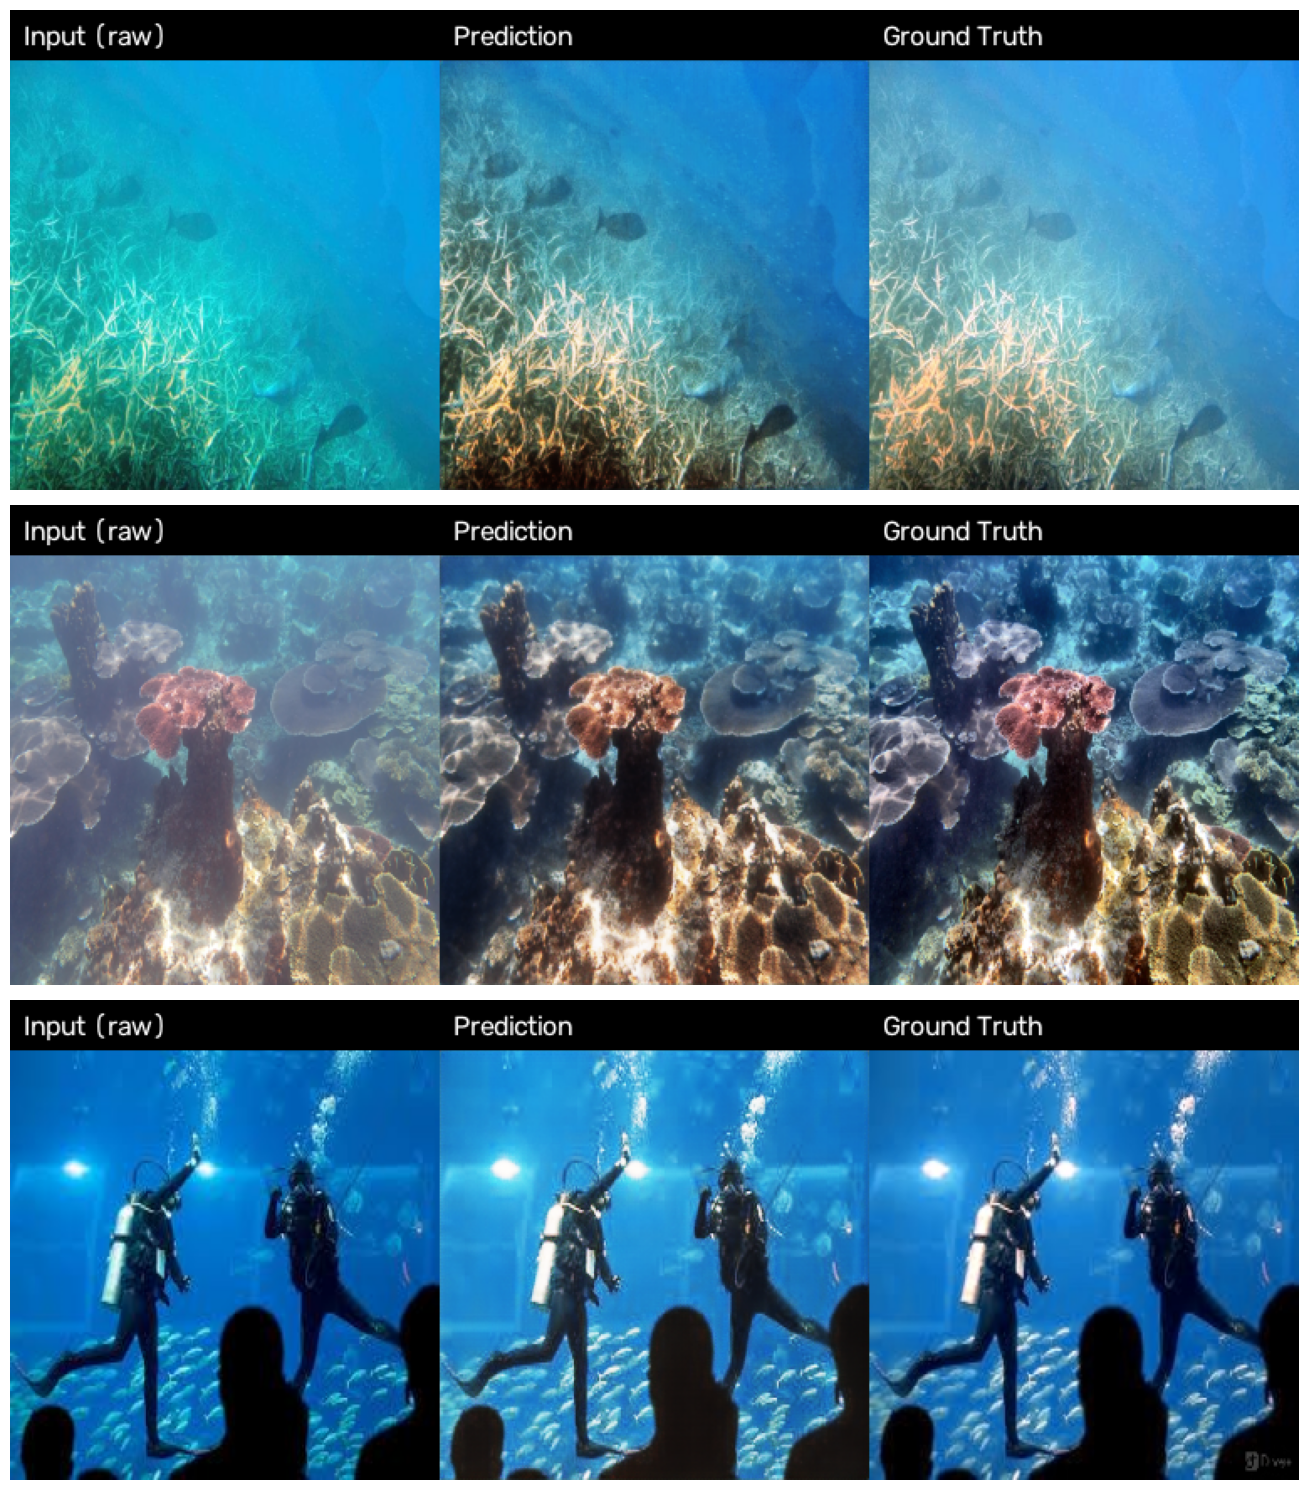

In [13]:
def put_title(image, title):
    """Add a black title bar ABOVE the image (the old version painted over the top 30 px of the image)."""
    bar = np.zeros((30, image.shape[1], 3), dtype=np.uint8)
    cv2.putText(bar, title, (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return np.vstack([bar, image])


def save_bgr(path, rgb):
    cv2.imwrite(str(path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


@torch.no_grad()
def dehaze_image(image_path, size=IMG_SIZE):
    """Run the model on one image; returns input, prediction and the forward-pass time in ms."""
    generator.eval()
    with Image.open(image_path) as im:
        rgb = np.array(im.convert("RGB"))
    rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    I = np_to_tensor(rgb).unsqueeze(0).to(DEVICE)

    sync()
    t0 = time.perf_counter()
    pred = enhance(I)
    sync()
    infer_ms = (time.perf_counter() - t0) * 1000.0

    return {"input": rgb, "prediction": tensor_to_uint8(pred), "infer_ms": infer_ms}


def compare_one(raw_path, ref_path, output_dir):
    stem = Path(raw_path).stem
    o = dehaze_image(raw_path)

    with Image.open(ref_path) as im:
        gt = cv2.resize(np.array(im.convert("RGB")), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    panels = [put_title(o["input"], "Input (raw)"), put_title(o["prediction"], "Prediction"), put_title(gt, "Ground Truth")]

    psnr = peak_signal_noise_ratio(gt, o["prediction"], data_range=255)
    # same SSIM definition as the training code (Gaussian window, sigma=1.5)
    ssim = structural_similarity(gt, o["prediction"], channel_axis=2, data_range=255,
                                 gaussian_weights=True, sigma=1.5, use_sample_covariance=False)
    uiqm = compute_uiqm(o["prediction"])
    print(f"{stem}: PSNR={psnr:.2f} SSIM={ssim:.4f} UIQM(pred)={uiqm:.3f} inference={o['infer_ms']:.1f}ms")

    save_bgr(Path(output_dir) / f"{stem}_input.png", o["input"])
    save_bgr(Path(output_dir) / f"{stem}_prediction.png", o["prediction"])
    save_bgr(Path(output_dir) / f"{stem}_ground_truth.png", gt)
    comparison = np.hstack(panels)
    save_bgr(Path(output_dir) / f"{stem}_comparison.png", comparison)
    return comparison, {"file": Path(raw_path).name, "psnr": psnr, "ssim": ssim, "uiqm": uiqm, "infer_ms": o["infer_ms"]}


N_COMPARE = 5   # number of test images

results = [compare_one(r, g, OUTPUT_DIR) for r, g in test_pairs[:N_COMPARE]]
comparisons = [c for c, _ in results]

comparison_csv = os.path.join(LOG_DIR, "comparison_metrics.csv")
with open(comparison_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file", "psnr", "ssim", "uiqm", "infer_ms"])
    writer.writeheader()
    writer.writerows(m for _, m in results)
print(f"Saved outputs to: {OUTPUT_DIR}\nPer-image metrics saved to {comparison_csv}")

# Display first 3 comparisons
show = comparisons[:3]
if show:
    plt.figure(figsize=(18, 5 * len(show)))
    for i, c in enumerate(show):
        plt.subplot(len(show), 1, i + 1)
        plt.imshow(c)
        plt.axis("off")
    plt.tight_layout()
    plt.show()